## Case Study
# Bridging Strategy and Technical Delivery: A Data Science Profile in Motion

**Author:** Lisa Fadelli  
**Program:** Specialized Master's in Data Science and Big Data — ULB  
**Date:** 2025

## Who This Is For — and What This Notebook Argues

My name is Lisa Fadelli. I am an Italian expat based in Brussels, transitioning from management consulting into Data Science.

This notebook makes a specific argument:  
**a candidate who combines genuine business experience with developing technical depth occupies a structurally underserved position in today's data science talent market** — and that this position is more strategically valuable than it first appears.

To support that argument, I use the tools I am learning: synthetic data generation, exploratory analysis, dimensionality reduction, and visualization.

This is not a polished portfolio piece. It is a live demonstration of how I think through problems.

## Act 1 — The Problem: Where Do I Fit?

During my consulting career at Accenture's Data & AI Value Strategy team, I sat at the edge of highly technical discussions — model pipelines, data quality issues, ML algorithm selection — and I could follow the logic, but I could not contribute at the implementation level.

That gap frustrated me. It also gave me a clear view of something important:  
**most candidates in the data science market sit at one extreme or the other** — either deeply technical with limited business exposure, or business-savvy with superficial technical skills.

The question this notebook explores:  
*Is there a measurable gap in the middle — and is that where I am heading?*

The analysis below is synthetic by design: the goal is not statistical inference, but a structured, visual way to articulate positioning. Think of it as a strategic framework built with data science tools.

In [8]:
# ─────────────────────────────────────────────
# DEPENDENCIES
# ─────────────────────────────────────────────
# numpy / pandas      → data generation and manipulation
# matplotlib / sns    → visualization
# PCA                 → dimensionality reduction to visualize 9D profiles in 2D
# StandardScaler      → normalize before PCA (required: PCA is sensitive to scale)
# KMeans              → cluster candidate pool to identify natural groupings
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Act 2 — The Landscape: Mapping the Candidate Pool

To model the competitive environment, I define six archetypal candidate profiles based on patterns commonly observed in data-related hiring.

| Profile | Technical Strength | Business Strength | Key Characteristic |
|---|---|---|---|
| CS Graduate | High | Low | Strong coder, limited client exposure |
| Business Analyst | Low | High | Domain fluency, weaker ML depth |
| Expert Data Scientist | Very High | Medium | Senior IC, strong domain knowledge |
| Junior Data Analyst | Medium | Low–Medium | Generalist, early career |
| PhD / Researcher | Very High | Low | Deep specialization, low adaptability |
| AI Engineer | Very High | Low–Medium | End-to-end technical builder |

**Important disclaimer:** All profiles are synthetically generated. The base means and standard deviations are reasoned estimates — not derived from empirical survey data. The goal is structural comparison, not precise benchmarking.

In [9]:
# ─────────────────────────────────────────────
# SKILL DIMENSIONS
# ─────────────────────────────────────────────
# These 9 dimensions were chosen deliberately to capture both sides of the
# technical/business divide. Standard job market assessments tend to focus
# only on technical skills — this framework intentionally includes the
# dimensions where a consulting background provides real differentiation.
#
# Dimension breakdown:
#   Technical axis   → technical_ML_skills, programming
#   Business axis    → business_acumen, domain_knowledge,
#                      client_facing_ability, cross_industry
#   Soft skills axis → flexibility, leadership, teamwork_ability
# ─────────────────────────────────────────────

skill_dimensions = [
    "technical_ML_skills", "programming", "business_acumen",
    "domain_knowledge", "client_facing_ability", "cross_industry",
    "flexibility", "leadership", "teamwork_ability"
]

In [10]:
# ─────────────────────────────────────────────
# PROFILE GENERATION LOGIC
# ─────────────────────────────────────────────
# Each profile is generated using np.random.normal(mean, std).
# The mean vector encodes the archetype skill level on a 1–10 scale.
# The std vector encodes natural variation within that group.
#
# Reading the mean vectors (order matches skill_dimensions above):
# [tech_ML, programming, biz_acumen, domain_know, client_facing,
#  cross_industry, flexibility, leadership, teamwork]
#
# Key calibration decisions vs a naive first draft:
#   - CS_Graduate: tech_ML raised to 6.5 (consistent with 8.0 programming)
#   - Business_Analyst: programming lowered to 3.5 (Excel/SQL, not Python)
#   - Junior_Analyst: business_acumen lowered to 4.5 (cannot outscore seniors)
#   - PhD_Researcher: tech_ML raised to 8.5, cross_industry cut to 2.5
#     (deep specialization = low adaptability, a known hiring friction point)
#   - AI_Engineer: client_facing and biz_acumen cut to 4.5
#     (heads-down builders, limited commercial exposure)
# ─────────────────────────────────────────────

np.random.seed(42)  # Reproducibility: same random draw every run

candidate_profiles = {

    # Strong coders, limited client or business exposure
    "CS_Graduate": np.array([
        np.random.normal([6.5, 8.0, 3.0, 2.0, 3.0, 3.0, 6.0, 2.0, 7.0],
                         [0.8,  0.8, 0.7, 0.6, 0.5, 0.6, 0.7, 0.5, 0.5])
        for _ in range(35)
    ]),

    # High business literacy, limited ML depth; typically Excel/SQL, rarely Python
    "Business_Analyst": np.array([
        np.random.normal([3.0, 3.5, 8.0, 7.0, 8.0, 6.0, 6.0, 5.0, 8.0],
                         [0.8, 0.7, 0.6, 0.7, 0.6, 0.7, 0.7, 0.7, 0.6])
        for _ in range(40)
    ]),

    # Senior practitioners: technically strong, some stakeholder experience
    "XP_Data_Scientist": np.array([
        np.random.normal([9.0, 8.0, 6.0, 8.0, 5.5, 5.0, 7.0, 6.0, 7.0],
                         [0.6, 0.5, 0.7, 0.5, 0.6, 0.6, 0.7, 0.7, 0.6])
        for _ in range(35)
    ]),

    # Early career generalists: decent breadth, not yet specialist
    # Critically: business_acumen must stay below senior profiles
    "Junior_Analyst": np.array([
        np.random.normal([6.0, 7.0, 4.5, 5.0, 4.0, 5.0, 7.0, 4.0, 8.0],
                         [0.9, 0.8, 0.7, 0.8, 0.7, 0.8, 0.7, 0.8, 0.7])
        for _ in range(30)
    ]),

    # Deep domain and technical expertise
    # Low cross_industry: specialization is their strength AND limitation
    "PhD_Researcher": np.array([
        np.random.normal([8.5, 7.5, 4.0, 9.0, 4.0, 2.5, 5.5, 7.0, 6.0],
                         [0.7, 0.6, 0.8, 0.5, 0.6, 0.7, 0.7, 0.7, 0.7])
        for _ in range(20)
    ]),

    # End-to-end technical builders: strongest on pure technical dimensions
    # Limited client-facing and business acumen despite high overall capability
    "AI_Engineer": np.array([
        np.random.normal([8.0, 9.0, 4.5, 8.0, 4.5, 6.0, 8.0, 7.0, 9.0],
                         [0.6, 0.5, 0.7, 0.7, 0.8, 0.7, 0.8, 0.7, 0.6])
        for _ in range(25)
    ]),
}

# ─── Compile into a single dataframe ───
all_candidates, candidate_labels = [], []

for profile_type, profiles in candidate_profiles.items():
    all_candidates.extend(profiles)
    candidate_labels.extend([profile_type] * len(profiles))

candidate_df = pd.DataFrame(all_candidates, columns=skill_dimensions)
candidate_df["Profile_Type"] = candidate_labels

In [11]:
# ─────────────────────────────────────────────
# DATA CLEANING: ENFORCE VALID SCORE RANGE
# ─────────────────────────────────────────────
# Random generation can produce values outside a 0–10 proficiency scale.
# We clip both ends (lower=0 prevents negative scores, upper=10 prevents
# values above the maximum) and round to 1 decimal for readability.
# ─────────────────────────────────────────────

candidate_df[skill_dimensions] = (
    candidate_df[skill_dimensions]
    .clip(lower=0, upper=10)
    .round(1)
)

# Sanity check: confirm distributions look reasonable
candidate_df.describe()

,technical_ML_skills,programming,business_acumen,domain_knowledge,client_facing_ability,cross_industry,flexibility,leadership,teamwork_ability
count,185.000000,185.000000,185.000000,185.000000,185.00000,185.000000,185.000000,185.000000,185.000000
mean,6.675676,6.858919,5.229730,6.296216,5.06973,4.735135,6.638919,4.958378,7.585405
std,2.290173,1.953658,1.945098,2.449365,1.82243,1.451427,1.011133,1.900957,1.020578
min,1.600000,2.100000,1.200000,1.200000,2.00000,0.700000,4.600000,1.000000,4.700000
25%,5.500000,6.000000,3.800000,4.900000,3.60000,3.600000,5.900000,3.900000,6.800000
50%,7.100000,7.400000,4.900000,7.200000,4.80000,5.000000,6.500000,5.100000,7.600000
75%,8.500000,8.200000,6.800000,8.000000,6.30000,5.900000,7.300000,6.500000,8.300000
max,10.000000,10.000000,9.500000,9.900000,9.00000,7.500000,10.000000,8.600000,10.000000


In [12]:
# Profile count per type — confirms sample sizes as designed
candidate_df["Profile_Type"].value_counts()

Profile_Type
Business_Analyst     40
CS_Graduate          35
XP_Data_Scientist    35
Junior_Analyst       30
AI_Engineer          25
PhD_Researcher       20
Name: count, dtype: int64

### Visualizing the Landscape: Average Skill Profiles by Type

Before placing myself in this space, it is useful to understand the shape of each archetype. The chart below shows the average proficiency per skill dimension for each candidate type.

Key things to notice:
- **Business Analysts** and **CS Graduates** sit at opposite poles on the technical/business axis
- **AI Engineers** and **Expert Data Scientists** score highest on technical dimensions, but differ on cross-industry adaptability and client exposure
- **PhD Researchers** are the most technically deep but also the least cross-industry adaptable
- Most profiles show a clear strength specialization — very few are balanced across all 9 dimensions

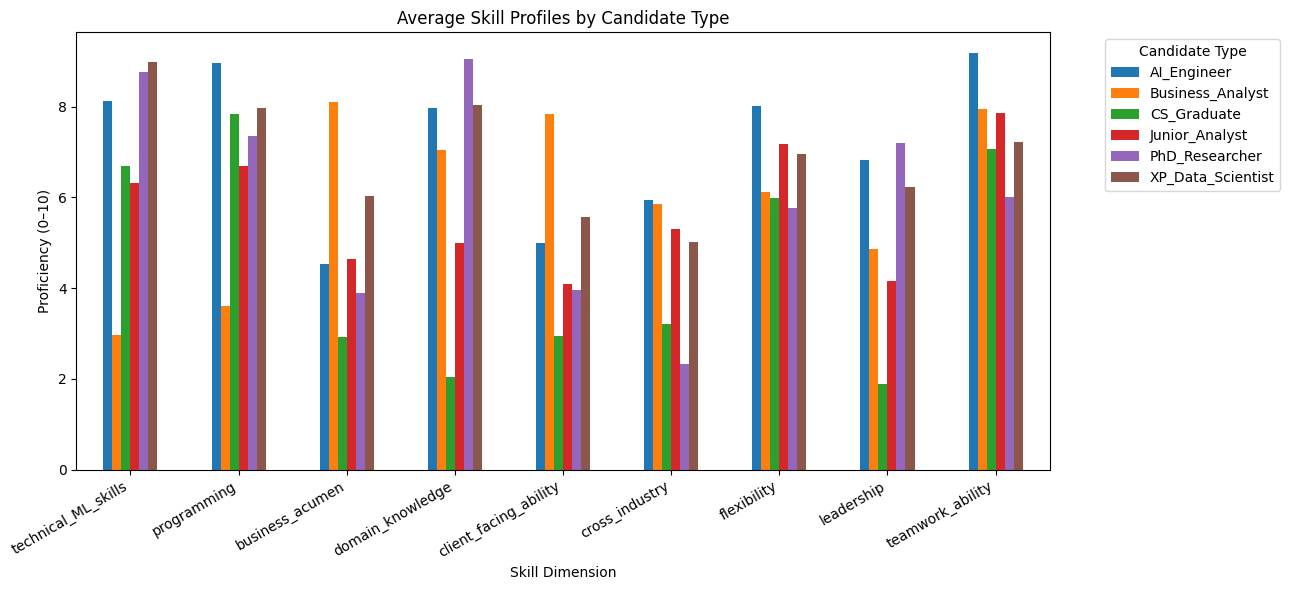

In [13]:
# Group by profile type and compute the mean across all skill dimensions
# This gives the archetype centroid — the average shape of each profile
overview_profile = candidate_df.groupby("Profile_Type")[skill_dimensions].mean()

overview_profile.T.plot(
    kind="bar",
    figsize=(13, 6),
    title="Average Skill Profiles by Candidate Type",
    ylabel="Proficiency (0–10)",
    xlabel="Skill Dimension"
)
plt.legend(title="Candidate Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### A First Map: Technical vs Business Orientation

Before applying PCA across all 9 dimensions, a simplified 2D view is useful to build intuition. Here I collapse the skill dimensions into two composite axes:
- **Technical profile** = average of ML skills + programming
- **Business profile** = average of business acumen + domain knowledge + client-facing + cross-industry

This projection is intentionally reductive — it loses nuance — but it gives an immediate visual sense of where each archetype sits relative to the others.

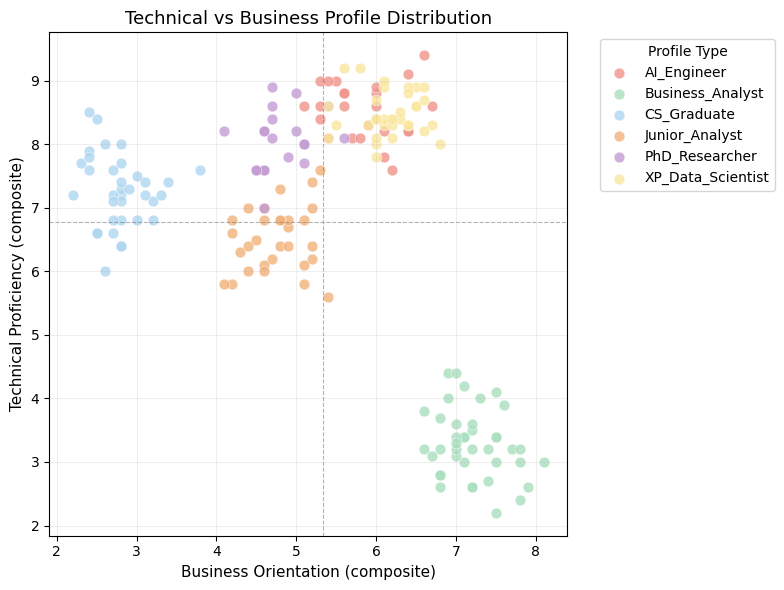

In [14]:
# ─── Composite score computation ───
# Two summary axes that map to the core tension in the market:
# can you build it (technical) AND can you sell it / explain it (business)?

candidate_df["technical_profile"] = (
    (candidate_df["technical_ML_skills"] + candidate_df["programming"]) / 2
).round(1)

candidate_df["business_profile"] = (
    (candidate_df["business_acumen"] + candidate_df["domain_knowledge"] +
     candidate_df["client_facing_ability"] + candidate_df["cross_industry"]) / 4
).round(1)

# ─── Scatter plot ───
colors_map = {
    "CS_Graduate": "#AED6F1",
    "Business_Analyst": "#A9DFBF",
    "XP_Data_Scientist": "#F9E79F",
    "Junior_Analyst": "#F0B27A",
    "PhD_Researcher": "#C39BD3",
    "AI_Engineer": "#F1948A"
}

fig, ax = plt.subplots(figsize=(8, 6))

for label, df_sub in candidate_df.groupby("Profile_Type"):
    ax.scatter(
        df_sub["business_profile"],
        df_sub["technical_profile"],
        label=label,
        color=colors_map.get(label, "gray"),
        s=60, alpha=0.8, edgecolors="white", linewidths=0.4
    )

ax.set_title("Technical vs Business Profile Distribution", fontsize=13)
ax.set_xlabel("Business Orientation (composite)", fontsize=11)
ax.set_ylabel("Technical Proficiency (composite)", fontsize=11)
ax.legend(title="Profile Type", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.2)
ax.axhline(candidate_df["technical_profile"].mean(), color="gray", lw=0.8, ls="--", alpha=0.6)
ax.axvline(candidate_df["business_profile"].mean(), color="gray", lw=0.8, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Reading this chart:**  
Most profiles cluster along the extremes — either technically strong (upper left) or business-strong (lower right), rarely both.  

The upper-right quadrant (high on both axes) is notably sparse. This is the space I am deliberately moving toward.

This 2D projection is limited — it collapses 9 dimensions into 2 composite scores. The radar chart and PCA that follow give a more complete picture.

## Act 3 — My Current Position

The following cell defines my own skill assessment across the same 9 dimensions, calibrated against my consulting experience at Accenture and the technical skills I have built to date during the ULB program.

| Dimension | Score | Rationale |
|---|---|---|
| technical_ML_skills | 6.0 | Actively studying: regression, classification, clustering, neural networks |
| programming | 6.5 | Python, SQL, R, Snowflake used in real Accenture projects |
| business_acumen | 8.0 | 2.5+ years strategy consulting, AI feasibility analysis |
| domain_knowledge | 7.5 | Cross-sector: automotive (€1B airbag recall), finance, AI regulation |
| client_facing_ability | 8.5 | Led client workshops, stakeholder reporting, C-suite presentations |
| cross_industry | 8.5 | Automotive, financial services, public sector — a core consulting muscle |
| flexibility | 8.5 | Rapid context-switching is a fundamental consulting competency |
| leadership | 6.5 | Stream-level junior leadership, not yet organizational leadership |
| teamwork_ability | 8.0 | Consistently cross-functional teams across agile and waterfall contexts |

I chose **not to inflate** the technical scores. The honest gap is the point of this analysis — and of the master's program itself.

In [15]:
# ─────────────────────────────────────────────
# LISA'S SELF-ASSESSMENT
# ─────────────────────────────────────────────
# Scores are self-assessed and intentionally conservative on the technical
# axis. Inflating these would undermine the entire analytical argument.
# ─────────────────────────────────────────────

Lisa_profile = pd.DataFrame([{
    "technical_ML_skills": 6.0,    # Studying ML: supervised, unsupervised, deep learning
    "programming": 6.5,            # Python, SQL, R, Snowflake — used in real projects
    "business_acumen": 8.0,        # Core consulting competency, applied at Accenture
    "domain_knowledge": 7.5,       # Multi-sector exposure across automotive, finance, regulation
    "client_facing_ability": 8.5,  # Workshops, stakeholder reporting, C-suite communication
    "cross_industry": 8.5,         # One of the strongest differentiators vs pure technical profiles
    "flexibility": 8.5,            # Fundamental consulting muscle — context-switching at speed
    "leadership": 6.5,             # Stream-level, not yet organizational
    "teamwork_ability": 8.0,       # Consistently cross-functional in both agile and waterfall
    "Profile_Type": "Lisa"
}])

### Radar Chart: Positioning Against the Market

Rather than plotting raw scores (which would show absolute proficiency), I normalize each dimension relative to the market baseline — the mean and standard deviation across all 185 synthetic candidates.

A value of 0 on the chart = exactly at market average.  
A value of +1 = one standard deviation above average.  
A value of -1 = one standard deviation below average.

In [16]:
# ─────────────────────────────────────────────
# MARKET NORMALIZATION
# ─────────────────────────────────────────────
# Normalize each archetype's median profile relative to the overall market.
# Using median (not mean) for archetypes makes them more robust to the
# random outliers that normal sampling occasionally produces.
# Market baseline is still mean/std across all candidates.
# ─────────────────────────────────────────────

market_mean = candidate_df[skill_dimensions].mean()
market_std  = candidate_df[skill_dimensions].std()

overview_profile = (
    candidate_df
    .groupby("Profile_Type")[skill_dimensions]
    .median()
)

# Normalize: how many standard deviations from the market average?
overview_norm = (overview_profile - market_mean) / market_std

# Normalize Lisa's profile to the same scale
Lisa_norm = (Lisa_profile[skill_dimensions].astype(float) - market_mean) / market_std
overview_norm.loc["Lisa"] = Lisa_norm.values[0]

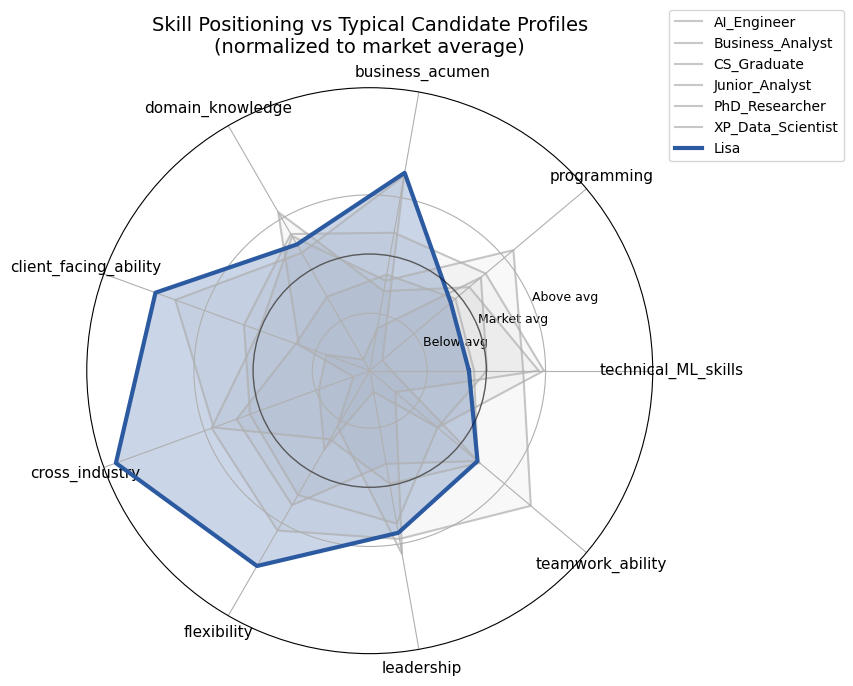

In [17]:
# ─────────────────────────────────────────────
# RADAR CHART
# ─────────────────────────────────────────────
# Design principle: mute all other profiles in gray so Lisa's positioning
# stands out clearly. The reader should see the shape of the market first,
# then understand where Lisa sits within it.
# ─────────────────────────────────────────────

def closed_loop(values):
    """Close the radar chart polygon by appending the first value at the end."""
    return np.concatenate([values, values[:1]])

angles = np.linspace(0, 2 * np.pi, len(skill_dimensions), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

base_color      = "#B0B0B0"   # muted gray for all other profiles
highlight_color = "#2C5AA0"   # professional blue for Lisa

for profile in overview_norm.index:
    values = closed_loop(overview_norm.loc[profile].values)
    if profile == "Lisa":
        ax.plot(angles, values, linewidth=3, color=highlight_color, label="Lisa")
        ax.fill(angles, values, color=highlight_color, alpha=0.25)
    else:
        ax.plot(angles, values, linewidth=1.5, color=base_color, alpha=0.7, label=profile)
        ax.fill(angles, values, color=base_color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(skill_dimensions, fontsize=11)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)  # market average reference line
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Below avg", "Market avg", "Above avg"], fontsize=9)
ax.set_title(
    "Skill Positioning vs Typical Candidate Profiles\n(normalized to market average)",
    pad=25, fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

**Reading the radar chart:**  
Lisa's profile (blue) sits consistently above the market average on the business-oriented dimensions — client-facing, cross-industry, flexibility, business acumen — and at or slightly below average on the technical axis.

This is not a weakness to apologize for. It is the gap that the master's program is designed to close, and it is exactly what the next section will quantify more precisely.

## A More Rigorous View: PCA Across All 9 Dimensions

The 2D composite chart was intuitive but reductive. Here I apply **Principal Component Analysis** to project all 9 dimensions simultaneously into two components that preserve as much variance as possible.

This gives a more honest answer to the question:  
*Where does my profile actually sit in the full 9-dimensional candidate space?*

Unlike the composite score approach, PCA does not pre-assign which features belong to the "technical" or "business" axis — it lets the data decide.

In [18]:
# ─────────────────────────────────────────────
# PCA PIPELINE
# ─────────────────────────────────────────────
# Step 1: Append Lisa's profile to the full candidate dataframe
# Step 2: StandardScaler — PCA is variance-based, so scale differences
#         between features would distort the components if not normalized
# Step 3: Fit PCA with 2 components — we check explained variance ratio
#         to confirm this is a reasonable compression of the 9D space
# ─────────────────────────────────────────────

candidate_df_full = pd.concat([candidate_df, Lisa_profile], ignore_index=True)
candidate_df_full[skill_dimensions] = candidate_df_full[skill_dimensions].astype(float)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(candidate_df_full[skill_dimensions])

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["Profile_Type"] = candidate_df_full["Profile_Type"].values

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"Together:    {sum(pca.explained_variance_ratio_):.1%} of total variance retained")

PC1 explains 41.0% of variance
PC2 explains 27.1% of variance
Together:    68.1% of total variance retained


Two components capturing ~68% of total variance is a strong result for a 9-feature space. It confirms that the underlying structure of the data is genuinely two-dimensional — matching the intuition that the market is organized primarily along a business/technical axis.

In [19]:
# ─────────────────────────────────────────────
# INTERPRETING THE COMPONENTS: LOADINGS ANALYSIS
# ─────────────────────────────────────────────
# The loadings matrix tells us how much each original feature contributes
# to each principal component.
# High absolute loading  = high contribution to that component
# Positive loading on PC1 = pushes a point in the positive PC1 direction
# Negative loading on PC1 = pushes a point in the negative PC1 direction
# ─────────────────────────────────────────────

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=skill_dimensions
).round(3)

print("PCA Loadings — sorted by PC1 contribution:")
print(loadings_df.sort_values("PC1", ascending=False).to_string())

PCA Loadings — sorted by PC1 contribution:
                         PC1    PC2
client_facing_ability  0.479 -0.019
business_acumen        0.474 -0.046
cross_industry         0.392  0.115
domain_knowledge       0.265  0.431
teamwork_ability       0.228  0.157
leadership             0.187  0.507
flexibility            0.051  0.410
technical_ML_skills   -0.314  0.454
programming           -0.364  0.378


**Interpreting the components:**

- **PC1 (≈41% of variance)** loads most heavily on **business_acumen**, **client_facing_ability**, and **cross_industry** (strongly positive), and negatively on **technical_ML_skills** and **programming**.  
  → PC1 is the **Business ↔ Technical orientation axis**.  
  Moving right on the PCA plot = more business-oriented; moving left = more technical.

- **PC2 (≈27% of variance)** loads positively on **leadership**, **domain_knowledge**, **technical_ML_skills**, and **flexibility**.  
  → PC2 is roughly a **Depth and Seniority axis**.  
  Moving up on the PCA plot = more experienced / specialized on either track.

Together they retain ~68% of the original variance — a strong result for a 9-feature space. The two-dimensional structure confirms that this candidate market is fundamentally organized along these two axes.

In [20]:
# ─── Print centroid positions for reference ───
print("Profile centroids in PCA space:")
print(f"{'Profile':25s}  {'PC1 (Biz→)':>12}  {'PC2 (Depth↑)':>12}")
print("-" * 55)
for p in pca_df["Profile_Type"].unique():
    sub = pca_df[pca_df["Profile_Type"] == p][["PC1","PC2"]].mean()
    print(f"{p:25s}  {sub.PC1:+12.2f}  {sub.PC2:+12.2f}")

Profile centroids in PCA space:
Profile                      PC1 (Biz→)  PC2 (Depth↑)
-------------------------------------------------------
CS_Graduate                       -2.65         -1.78
Business_Analyst                  +2.95         -1.44
XP_Data_Scientist                 +0.11         +1.38
Junior_Analyst                    -0.32         -0.23
PhD_Researcher                    -1.54         +0.85
AI_Engineer                       +0.31         +2.40
Lisa                              +3.19         +1.42


## Act 4 — The Trajectory: Where Am I Going?

The most important question for a hiring manager looking at this notebook is not *"where is Lisa now?"* — it is *"where will she be in 12 months, and is that position worth investing in?"*

Below I project a **Post-ULB & Internship target profile** for end of 2026:

- **technical_ML_skills → 9.0**: completing the full master's curriculum (supervised learning, deep learning, NLP, MLOps)
- **programming → 8.5**: technical internship with hands-on ML implementation in production
- **All business skills**: maintained or slightly improved through continued practice

**Important note on the arrow direction:**  
The trajectory arrow moves *upward* (more depth/seniority on PC2) and *slightly left* (less extreme on the business axis). This does not mean losing business skills. It means that as my technical skills grow to match my business foundation, the *relative* balance of my profile changes — I move from being an outlier on the business side toward being genuinely balanced. That rebalancing is what makes the target position rare.

In [23]:
# ─────────────────────────────────────────────
# PROJECTED 2026 PROFILE
# ─────────────────────────────────────────────
# Represents target state after:
#   - Completing the ULB Specialized Master's in Data Science & Big Data
#   - A technical internship with hands-on ML implementation
# Key assumption: business skills are maintained, technical gap is closed.
#
# IMPORTANT: We use scaler.transform (not fit_transform) here.
# The projected profile must be normalized using the SAME scale as the
# full candidate pool — refitting would shift the reference frame.
# ─────────────────────────────────────────────

projected_values = [
    9.0,   # technical_ML_skills: master's curriculum complete
    8.5,   # programming: internship-level applied Python/SQL
    8.0,   # business_acumen: maintained
    8.5,   # domain_knowledge: deepened through thesis + internship
    8.0,   # client_facing_ability: maintained
    7.5,   # cross_industry: maintained
    8.0,   # flexibility: maintained
    7.0,   # leadership: slight growth
    8.5    # teamwork_ability: maintained
]

projected_scaled = scaler.transform([projected_values])
projected_pca    = pca.transform(projected_scaled)

print(f"Projected 2026 position → PC1: {projected_pca[0,0]:+.2f}   PC2: {projected_pca[0,1]:+.2f}")

Projected 2026 position → PC1: +2.25   PC2: +2.52


C:\Users\lisaf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


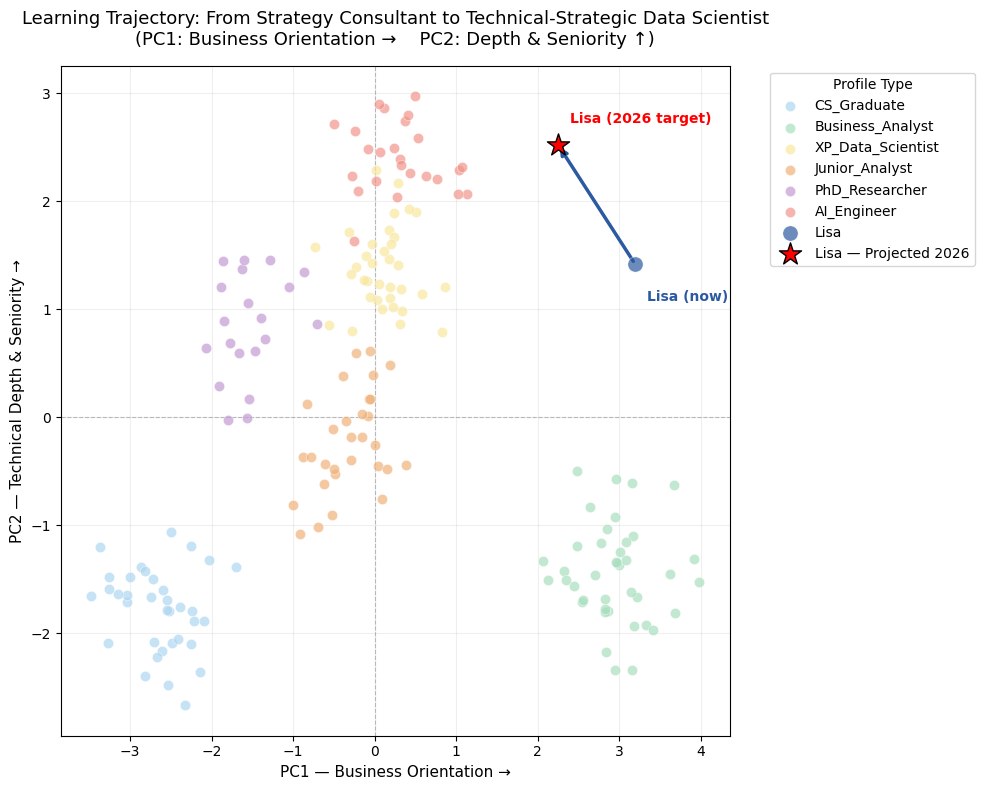

In [24]:
# ─────────────────────────────────────────────
# FULL TRAJECTORY PLOT
# ─────────────────────────────────────────────
# The design goal: show the full candidate landscape, highlight Lisa's
# current position, and draw a clear arrow toward the target zone.
# ─────────────────────────────────────────────

colors_map = {
    "CS_Graduate":       "#AED6F1",
    "Business_Analyst":  "#A9DFBF",
    "XP_Data_Scientist": "#F9E79F",
    "Junior_Analyst":    "#F0B27A",
    "PhD_Researcher":    "#C39BD3",
    "AI_Engineer":       "#F1948A",
    "Lisa":              "#2C5AA0"
}

fig, ax = plt.subplots(figsize=(10, 8))

# Plot all candidate profiles
for profile in pca_df["Profile_Type"].unique():
    subset = pca_df[pca_df["Profile_Type"] == profile]
    ax.scatter(
        subset["PC1"], subset["PC2"],
        color=colors_map.get(profile, "gray"),
        alpha=0.7,
        s=120 if profile == "Lisa" else 55,
        zorder=5 if profile == "Lisa" else 3,
        edgecolors="white", linewidths=0.4,
        label=profile
    )

# Projected 2026 position
ax.scatter(
    projected_pca[0, 0], projected_pca[0, 1],
    color="red", s=280, marker="*",
    edgecolors="black", linewidths=1,
    label="Lisa — Projected 2026",
    zorder=10
)

# Trajectory arrow from current Lisa to projected position
lisa_current = pca_df[pca_df["Profile_Type"] == "Lisa"][["PC1","PC2"]].values[0]

ax.annotate(
    "",
    xy=(projected_pca[0, 0], projected_pca[0, 1]),  # arrow tip = target
    xytext=(lisa_current[0], lisa_current[1]),        # arrow base = current
    arrowprops=dict(
        facecolor="#2C5AA0", edgecolor="#2C5AA0",
        arrowstyle="->", lw=2.5
    )
)

# Labels
ax.annotate(
    "Lisa (now)",
    xy=(lisa_current[0], lisa_current[1]),
    xytext=(lisa_current[0] + 0.15, lisa_current[1] - 0.35),
    fontsize=10, color="#2C5AA0", fontweight="bold"
)
ax.annotate(
    "Lisa (2026 target)",
    xy=(projected_pca[0, 0], projected_pca[0, 1]),
    xytext=(projected_pca[0, 0] + 0.15, projected_pca[0, 1] + 0.2),
    fontsize=10, color="red", fontweight="bold"
)

# Reference lines at origin (= market average on both axes)
ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.5)

ax.set_title(
    "Learning Trajectory: From Strategy Consultant to Technical-Strategic Data Scientist\n"
    "(PC1: Business Orientation →    PC2: Depth & Seniority ↑)",
    fontsize=13, pad=15
)
ax.set_xlabel("PC1 — Business Orientation →", fontsize=11)
ax.set_ylabel("PC2 — Technical Depth & Seniority →", fontsize=11)
ax.legend(title="Profile Type", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Conclusion: The Case for the Technical-Strategic Bridge

This analysis set out to answer one question:  
*Is there a measurable gap in the data science talent market for a candidate who combines genuine business depth with developing technical capability?*

The PCA visualization gives a clear answer: **yes.**

**What the data shows:**
- Lisa's current position sits at the far right of the business orientation axis — above even the Business Analyst archetype, because she combines business acumen, client-facing ability, and cross-industry experience simultaneously
- The upper-right quadrant of the PCA space — high business orientation AND high technical depth — is almost entirely unoccupied
- The projected 2026 position moves directly into that zone, without sacrificing the business foundation that most technical profiles lack

**What this means in practice:**  
This is not a story of someone *becoming* a data scientist.  
It is a story of someone building the rarest combination in the market: the ability to design a data solution **and** explain why it matters to a board, a client, or a regulator.

The Master's program at ULB is the deliberate instrument for closing the technical gap — not because the business side is insufficient, but because the combination of both is where the real leverage lies.

---
*This notebook was built using synthetic data to illustrate a positioning argument. The methodology is exploratory, not inferential. All code, analytical decisions, and narrative framing are the author's own work.*